# Plotting Subgoal Proposer

In [1]:
# PATH = '/home/jennifer/scratch/aorl2/2026-03-16-00/2026-03-16-00.682e4de5697b9c301a2fa322d299ef547e570517f079b5019aacc5dfc5697c07/'
# PATH = '../../scratch/aorl2/2026-03-16-00/2026-03-16-00.0dfb77fdff1e9bb91c8f7575c8ad2c3f7d867f93572cfb2780acc46d86598233/'
# CKPT_NUM = 1000000

PATH = '../../scratch/aorl2/2026-03-26-00/2026-03-26-00.9b6c1eaf8f1d40255c6105757ba0c0d4da7efd3b59da3b3a2305d7fe3d773ad8'
CKPT_NUM = 1100000

In [2]:
import glob
import json
import os
import pathlib
import random
import signal
import sys
import time
from collections import defaultdict

import jax
import numpy as np
import tqdm
import wandb
import wandb.util
from absl import app, flags
from ml_collections import config_flags

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset, ReplayBuffer
from utils.flax_utils import restore_agent, save_agent
from utils.log_utils import CsvLogger, get_animal, get_exp_name, get_flag_dict, setup_wandb
from utils.plot_utils import plot_heatmap
from utils.samplers import to_oracle_rep
from utils.statistics import get_statistics_class
from wrappers.datafuncs_utils import clip_dataset, make_env_and_datasets
from utils.evaluation import evaluate_gcfql, evaluate
from ogbench.relabel_utils import add_oracle_reps, relabel_dataset

# Simplified setup - manually set the key flags
# FLAGS = flags.FLAGS

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [4]:
flags_file = os.path.join(PATH, 'flags.json')
with open(flags_file, 'r') as f:
    saved_flags = json.load(f)

print(saved_flags.keys())

dict_keys(['logtostderr', 'alsologtostderr', 'log_dir', 'v', 'verbosity', 'logger_levels', 'stderrthreshold', 'showprefixforinfo', 'run_with_pdb', 'pdb_post_mortem', 'pdb', 'run_with_profiling', 'profile_file', 'use_cprofile_for_profiling', 'only_check_args', 'chex_n_cpu_devices', 'chex_assert_multiple_cpu_devices', 'test_srcdir', 'test_tmpdir', 'test_random_seed', 'test_randomize_ordering_seed', 'xml_output_file', 'chex_skip_pmap_variant_if_single_device', 'pymjcf_debug', 'pymjcf_debug_full_dump_dir', 'pymjcf_log_xml', 'timeout', 'wbproj', 'run_group', 'seed', 'wandb_alerts', 'env_name', 'dataset_dir', 'agent', 'fql_agent', 'save_dir', 'offline_steps', 'further_offline_steps', 'log_interval', 'eval_interval', 'save_interval', 'collection_steps', 'data_plot_interval', 'cleanup', 'steps_toward_sg', 'subgoal_reached_distance', 'num_subgoal_candidates', 'use_triangle', 'triangle_threshold', 'use_rnd_bonus', 'rnd_bonus_weight', 'rnd_update_freq', 'rnd_lr', 'rnd_coeff', 'rnd_hidden_dims', '

In [5]:
# Print FLAGS in a readable format
print("Current FLAGS:")
for flag_name in sorted(dir(saved_flags)):
    if not flag_name.startswith('_'):
        try:
            value = getattr(saved_flags, flag_name)
            if not callable(value):
                print(f"  {flag_name}: {value}")
        except:
            pass

Current FLAGS:


In [6]:
agent_config = saved_flags['agent']
print(agent_config.keys())

dict_keys(['action_chunking', 'action_dim', 'actor_geom_sample', 'actor_hidden_dims', 'actor_p_curgoal', 'actor_p_randomgoal', 'actor_p_trajgoal', 'agent_name', 'alpha', 'awr_invtemp', 'batch_size', 'best_of_n', 'critic_loss_type', 'dataset_class', 'discount', 'flow_steps', 'gc_negative', 'goal_proposer_type', 'horizon_length', 'layer_norm', 'lr', 'num_qs', 'ob_dims', 'q_agg', 'subgoal_steps', 'tau', 'train_goal_proposer', 'train_value', 'value_geom_sample', 'value_hidden_dims', 'value_p_curgoal', 'value_p_randomgoal', 'value_p_trajgoal'])


In [9]:
train_dataset = np.load(os.path.join(PATH, 'data-100000.npz'))

In [10]:
from utils.datasets import GCDataset

train_dataset = GCDataset(Dataset.create(**train_dataset), config=agent_config)

In [11]:
example_batch = train_dataset.sample(1)
example_batch.keys()

dict_keys(['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals', 'value_goals', 'actor_goals', 'masks', 'rewards', 'low_actor_goals'])

In [12]:
# Use saved_flags directly instead of FLAGS
# env_name = saved_flags['env_name']
# dataset_dir = saved_flags.get('dataset_dir', '/home/jennifer/scratch/data/humanoidmaze-medium-navigate-v0')
# agent_config = saved_flags.get('agent', {
#     'agent_name': 'gcfql',
#     'train_goal_proposer': True,
#     'goal_proposer_type': 'low_actor_goals',
#     'train_value': True,
#     'horizon_length': 25,
#     'action_chunking': False,
#     'num_qs': 10,
#     'q_agg': 'mean',
#     'discount': 0.995,
#     'batch_size': 256,
#     'alpha': 30.0,
#     'subgoal_steps': 25,
#     'awr_invtemp': 0.0,
# })
seed = saved_flags.get('seed', 0)

# Create environment
# datasets = [file for file in sorted(glob.glob(f'{saved_flags["dataset_dir"]}/*.npz')) if '-val.npz' not in file]
# dataset_idx = 0
# splits = saved_flags['env_name'].split('-')
# env_name = '-'.join(splits[:-3]) + '-v0'
# env, train_dataset_data, val_dataset_data = make_env_and_datasets(
#     env_name,
#     dataset_path=datasets[dataset_idx],
#     use_oracle_reps=True,
# )

# Get a sample observation and goal
# train_dataset = GCDataset(Dataset.create(**train_dataset_data, freeze=False), agent_config)
example_batch = train_dataset.sample(1)
observation = example_batch['observations'][0]
# goal = example_batch['goals'][0]

# Restore agent
# agent_config = FLAGS.agent
agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
agent = restore_agent(agent, PATH, CKPT_NUM)

Restored from ../../scratch/aorl2/2026-03-26-00/2026-03-26-00.9b6c1eaf8f1d40255c6105757ba0c0d4da7efd3b59da3b3a2305d7fe3d773ad8/params_1100000.pkl


```
{'task_name': 'task4', 'init_ij': (6, 5), 'init_xy': (16.0, 20.0), 'goal_ij': (6, 1), 'goal_xy': (0.0, 20.0)}
```

In [13]:
goal = np.array([0.0, 20.0])

In [14]:
# Sample 128 subgoals
rng = jax.random.PRNGKey(seed)
observations = np.repeat(observation[None], 128, axis=0)
goals = np.repeat(goal[None], 128, axis=0)
subgoals = np.asarray(agent.propose_goals(observations, goals, rng))

print(f"Sampled {len(subgoals)} subgoals")
print(f"Observation: {observation}")
print(f"Goal: {goal}")
print(f"First few subgoals: {subgoals[:5]}")

Sampled 128 subgoals
Observation: [ 1.94162731e+01  1.92155209e+01  1.30483195e-01 -1.95103675e-01
  6.95254058e-02  1.03609219e-01 -7.63306975e-01  2.94551253e-01
  2.42505699e-01 -3.56841624e-01 -6.07629716e-01  9.86673534e-02
 -8.04082334e-01 -1.00508541e-01  4.71443087e-02 -7.11011767e-01
 -2.93089479e-01  5.56111276e-01  1.05528438e+00  8.81931424e-01
 -1.06381238e+00 -9.97232676e-01  8.81739974e-01  1.43080282e+00
  3.79133932e-02  1.66737035e-01  1.61419407e-01  2.83174872e-01
  2.17921525e-01 -1.17526078e+00  1.53273446e-02 -1.32089153e-01
  1.60245091e-01  9.56120938e-02  1.23193242e-01 -1.21280193e+00
  4.47198302e-02  4.72129025e-02  9.97883320e-01 -4.41413522e-01
  4.01029617e-01  9.59385037e-02 -4.68659520e-01  5.82087278e-01
  2.72689402e-01 -8.64999741e-02  5.54855633e+00 -1.11243236e+00
  2.67040014e-01 -6.10499811e+00 -2.18165851e+00 -1.90848887e-01
 -4.76491261e+00 -4.44014454e+00 -2.54769778e+00  2.05233307e+01
  1.61964607e+01 -1.60222304e+00 -1.91908026e+00 -1.7051

In [15]:
subgoals

array([[18.68519 , 19.52231 ],
       [19.027079, 19.428759],
       [18.77748 , 19.223839],
       [19.094654, 19.57037 ],
       [18.619911, 19.54675 ],
       [18.660997, 19.446709],
       [18.639027, 19.36377 ],
       [18.582664, 19.630299],
       [18.816895, 19.481112],
       [18.857563, 19.375643],
       [18.85091 , 19.386797],
       [18.643219, 19.438839],
       [18.799864, 19.286715],
       [18.64666 , 19.329294],
       [18.731905, 19.382456],
       [18.916716, 19.480507],
       [18.724771, 19.539185],
       [18.913094, 19.405869],
       [18.742785, 19.362303],
       [18.511171, 19.399168],
       [18.819586, 19.388372],
       [18.779037, 19.594244],
       [18.70956 , 19.397573],
       [18.723402, 19.247238],
       [18.921774, 19.341042],
       [19.018927, 19.430864],
       [18.605394, 19.467272],
       [18.635128, 19.5746  ],
       [18.554413, 19.372059],
       [18.672384, 19.254726],
       [18.733646, 19.634789],
       [18.732754, 19.49049 ],
       [

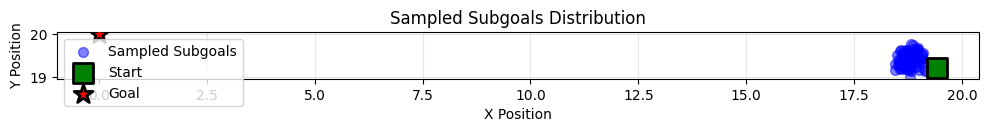

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot subgoals as scatter
ax.scatter(subgoals[:, 0], subgoals[:, 1], alpha=0.5, s=50, label='Sampled Subgoals', color='blue')

# Plot starting observation
ax.scatter(observation[0], observation[1], s=200, marker='s', color='green', label='Start', zorder=5, edgecolors='black', linewidth=2)

# Plot goal
ax.scatter(goal[0], goal[1], s=200, marker='*', color='red', label='Goal', zorder=5, edgecolors='black', linewidth=2)

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Sampled Subgoals Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [17]:
train_dataset.sample(1).keys()
# ['low_actor_goals']

dict_keys(['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals', 'value_goals', 'actor_goals', 'masks', 'rewards', 'low_actor_goals'])

In [18]:
# First inspect the batch structure
batch = train_dataset.sample(4)
print("Batch keys:", batch.keys())
print("\nBatch shapes:")
for key, val in batch.items():
    print(f"  {key}: {val.shape}")
print("\nFirst observation:", batch['observations'][0])
if 'value_goals' in batch:
    print("First value_goal:", batch['value_goals'][0])
if 'actor_goals' in batch:
    print("First actor_goal:", batch['actor_goals'][0])
if 'low_actor_goals' in batch:
    print("First low_actor_goal:", batch['low_actor_goals'][0])

Batch keys: dict_keys(['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals', 'value_goals', 'actor_goals', 'masks', 'rewards', 'low_actor_goals'])

Batch shapes:
  actions: (4, 21)
  next_observations: (4, 69)
  observations: (4, 69)
  oracle_reps: (4, 2)
  qpos: (4, 28)
  qvel: (4, 27)
  terminals: (4,)
  value_goals: (4, 2)
  actor_goals: (4, 2)
  masks: (4,)
  rewards: (4,)
  low_actor_goals: (4, 2)

First observation: [ 17.443481    13.799537     0.28528118  -0.14629473   0.46932417
  -0.4576114   -0.40860382  -1.8392003    0.04382652  -0.68436766
   0.92993253  -0.3427331   -0.58212626   0.14233553  -2.7651436
  -0.8832289    0.8853673   -1.768431    -1.4872878    0.52900636
  -1.0584885   -0.35667905   0.795342     0.41911408   0.1036777
   0.12173864   0.13125204  -0.15798432   0.06842574  -0.5080081
  -0.06970075  -0.31304687   0.20366263   0.72063106  -0.07892779
  -0.13699102   0.3537207    0.92710906   0.1238969   -0.9413418
   0.0244557

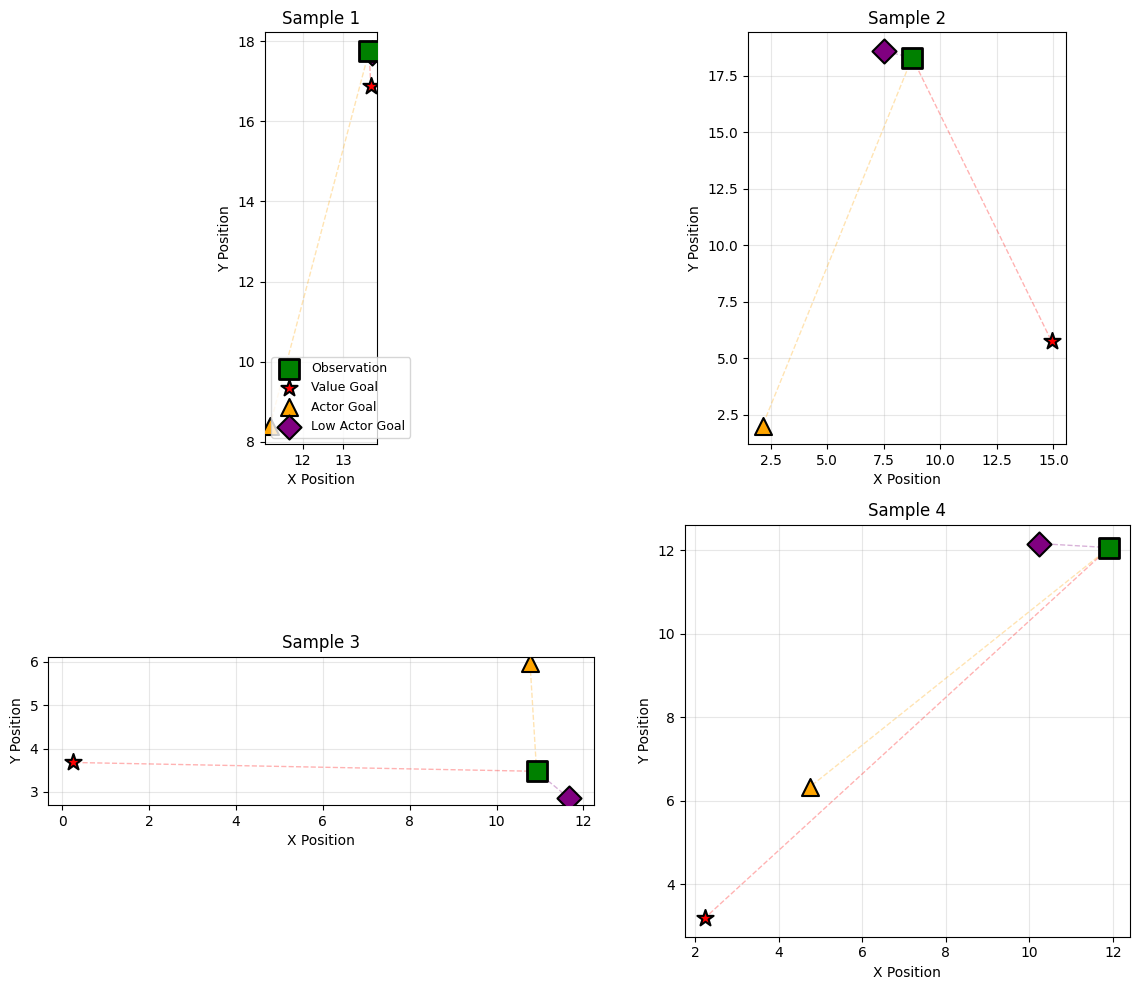

Observation positions (oracle_reps):
[[13.656123  17.750957 ]
 [ 8.756888  18.296362 ]
 [10.921463   3.4761345]
 [11.914372  12.059746 ]]

Value Goals:
[[13.699059   16.883905  ]
 [14.919135    5.7565975 ]
 [ 0.24519673  3.6795762 ]
 [ 2.232861    3.1931512 ]]

Actor Goals:
[[11.183364   8.407696 ]
 [ 2.1432462  2.0327973]
 [10.770458   5.963901 ]
 [ 4.74602    6.3304296]]

Low Actor Goals:
[[13.732843  17.69459  ]
 [ 7.4957843 18.587572 ]
 [11.671126   2.8549452]
 [10.236788  12.157122 ]]


In [19]:
# Sample a few batches and plot observations with different goal types
batch = train_dataset.sample(4)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx in range(4):
    ax = axes[idx]
    
    # Get observation position (oracle representation - 2D coordinates)
    obs_pos = batch['oracle_reps'][idx]
    
    # Get different goal types
    value_goal = batch['value_goals'][idx]
    actor_goal = batch['actor_goals'][idx]
    low_actor_goal = batch['low_actor_goals'][idx]
    
    # Plot observation position
    ax.scatter(obs_pos[0], obs_pos[1], s=200, marker='s', color='green', label='Observation', zorder=5, edgecolors='black', linewidth=2)
    
    # Plot goals
    ax.scatter(value_goal[0], value_goal[1], s=150, marker='*', color='red', label='Value Goal', zorder=4, edgecolors='black', linewidth=1.5)
    ax.scatter(actor_goal[0], actor_goal[1], s=150, marker='^', color='orange', label='Actor Goal', zorder=4, edgecolors='black', linewidth=1.5)
    ax.scatter(low_actor_goal[0], low_actor_goal[1], s=150, marker='D', color='purple', label='Low Actor Goal', zorder=4, edgecolors='black', linewidth=1.5)
    
    # Draw lines connecting observation to each goal type
    ax.plot([obs_pos[0], value_goal[0]], [obs_pos[1], value_goal[1]], 'r--', alpha=0.3, linewidth=1)
    ax.plot([obs_pos[0], actor_goal[0]], [obs_pos[1], actor_goal[1]], 'orange', linestyle='--', alpha=0.3, linewidth=1)
    ax.plot([obs_pos[0], low_actor_goal[0]], [obs_pos[1], low_actor_goal[1]], 'purple', linestyle='--', alpha=0.3, linewidth=1)
    
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_title(f'Sample {idx + 1}')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    if idx == 0:
        ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

# Print statistics
print("Observation positions (oracle_reps):")
print(batch['oracle_reps'])
print("\nValue Goals:")
print(batch['value_goals'])
print("\nActor Goals:")
print(batch['actor_goals'])
print("\nLow Actor Goals:")
print(batch['low_actor_goals'])

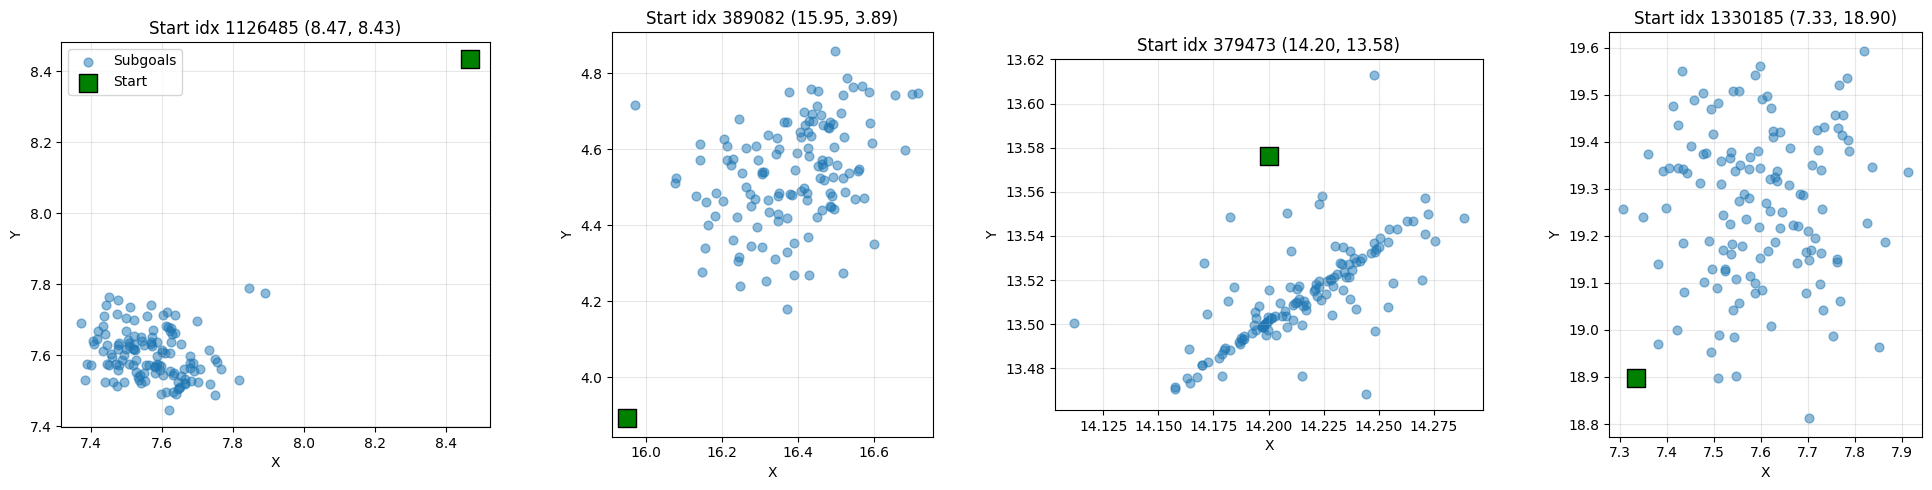

In [20]:
# Sample 128 subgoals from a few different starting observations and plot them
num_starts = 4
num_subgoals = 128

# Collect starting observations from the base dataset (full state vector)
start_indices = np.random.choice(len(train_dataset.dataset['observations']), size=num_starts, replace=False)
starts = train_dataset.dataset['observations'][start_indices]

fig, axes = plt.subplots(1, num_starts, figsize=(5 * num_starts, 5), squeeze=False)

for i, start_idx in enumerate(start_indices):
    ax = axes[0, i]
    start_obs = train_dataset.dataset['observations'][start_idx]
    start_pos = train_dataset.dataset['oracle_reps'][start_idx]

    # Batch the same start observation for multiple proposals
    obs_batch = np.repeat(start_obs[None, :], num_subgoals, axis=0)

    # Use an external goal (oracle representation) as placeholder. Could use actual end-goal if available.
    goal = np.array([0., 0.])
    goal_batch = np.repeat(goal[None, :], num_subgoals, axis=0)

    rng = jax.random.PRNGKey(seed + i + 1)
    subgoals = np.asarray(agent.propose_goals(obs_batch, goal_batch, rng))

    # Plot in oracle space
    ax.scatter(subgoals[:, 0], subgoals[:, 1], alpha=0.5, s=40, label='Subgoals')
    ax.scatter(start_pos[0], start_pos[1], s=180, marker='s', c='green', edgecolors='black', label='Start', zorder=5)
    ax.set_title(f'Start idx {start_idx} ({start_pos[0]:.2f}, {start_pos[1]:.2f})')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [21]:
observation

array([ 1.94162731e+01,  1.92155209e+01,  1.30483195e-01, -1.95103675e-01,
        6.95254058e-02,  1.03609219e-01, -7.63306975e-01,  2.94551253e-01,
        2.42505699e-01, -3.56841624e-01, -6.07629716e-01,  9.86673534e-02,
       -8.04082334e-01, -1.00508541e-01,  4.71443087e-02, -7.11011767e-01,
       -2.93089479e-01,  5.56111276e-01,  1.05528438e+00,  8.81931424e-01,
       -1.06381238e+00, -9.97232676e-01,  8.81739974e-01,  1.43080282e+00,
        3.79133932e-02,  1.66737035e-01,  1.61419407e-01,  2.83174872e-01,
        2.17921525e-01, -1.17526078e+00,  1.53273446e-02, -1.32089153e-01,
        1.60245091e-01,  9.56120938e-02,  1.23193242e-01, -1.21280193e+00,
        4.47198302e-02,  4.72129025e-02,  9.97883320e-01, -4.41413522e-01,
        4.01029617e-01,  9.59385037e-02, -4.68659520e-01,  5.82087278e-01,
        2.72689402e-01, -8.64999741e-02,  5.54855633e+00, -1.11243236e+00,
        2.67040014e-01, -6.10499811e+00, -2.18165851e+00, -1.90848887e-01,
       -4.76491261e+00, -

In [22]:
goal

array([0., 0.])

In [23]:
train_dataset.config['subgoal_steps']

25

Reference position: [19.416273 19.21552 ]
Found 15149 observations within distance 1.0 of reference position
Subgoal steps: 25
Low actor goals shape: (15149, 2)


/tmp/ipykernel_3135517/2695784796.py:71: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


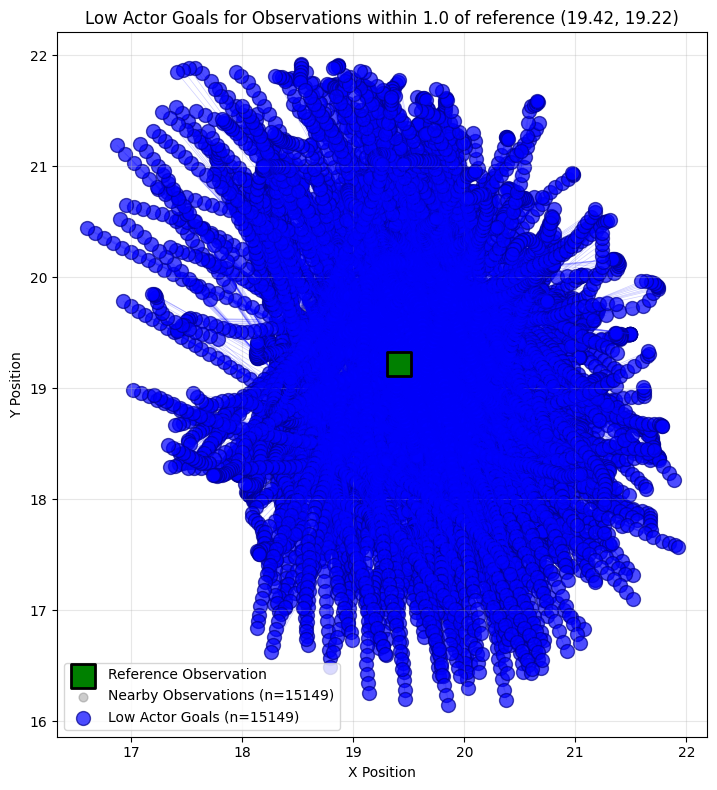

In [24]:
# Pick a reference observation and find nearby observations in the dataset
ref_observation = observation  # Use the observation from earlier
ref_pos = ref_observation[:2]  # Get x, y coordinates

print(f"Reference position: {ref_pos}")

# Access the underlying dataset
underlying_dataset = train_dataset.dataset

# Get data arrays
oracle_reps = underlying_dataset['oracle_reps']
terminals = underlying_dataset['terminals']

# Find terminal locations for trajectory boundaries
(terminal_locs,) = np.nonzero(terminals > 0)
initial_locs = np.concatenate([[0], terminal_locs[:-1] + 1])

# Get subgoal_steps from config
subgoal_steps = train_dataset.config.get('subgoal_steps', 25)

# Find all observations within distance 1.0
nearby_indices = []
nearby_low_actor_goals = []
nearby_positions = []

for idx in range(len(oracle_reps)):
    obs_pos = oracle_reps[idx]
    distance = np.linalg.norm(obs_pos - ref_pos)
    
    if distance <= 1.0:
        nearby_indices.append(idx)
        nearby_positions.append(obs_pos)
        
        # Compute low_actor_goal index (which is idx + subgoal_steps, clipped to trajectory end)
        final_state_idx = terminal_locs[np.searchsorted(terminal_locs, idx)]
        low_actor_goal_idx = np.minimum(idx + subgoal_steps, final_state_idx)
        nearby_low_actor_goals.append(oracle_reps[low_actor_goal_idx])

nearby_low_actor_goals = np.array(nearby_low_actor_goals)
nearby_positions = np.array(nearby_positions)

print(f"Found {len(nearby_indices)} observations within distance 1.0 of reference position")
print(f"Subgoal steps: {subgoal_steps}")
print(f"Low actor goals shape: {nearby_low_actor_goals.shape}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot reference observation
ax.scatter(ref_pos[0], ref_pos[1], s=300, marker='s', color='green', label='Reference Observation', zorder=5, edgecolors='black', linewidth=2)

# Plot nearby observations
ax.scatter(nearby_positions[:, 0], nearby_positions[:, 1], alpha=0.4, s=40, label=f'Nearby Observations (n={len(nearby_positions)})', color='gray')

# Plot nearby low actor goals
ax.scatter(nearby_low_actor_goals[:, 0], nearby_low_actor_goals[:, 1], alpha=0.7, s=100, label=f'Low Actor Goals (n={len(nearby_low_actor_goals)})', color='blue', edgecolors='darkblue', linewidth=1)

# Draw connecting lines
for i in range(len(nearby_positions)):
    ax.plot([nearby_positions[i, 0], nearby_low_actor_goals[i, 0]], 
            [nearby_positions[i, 1], nearby_low_actor_goals[i, 1]], 
            'b-', alpha=0.2, linewidth=0.5)

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title(f'Low Actor Goals for Observations within 1.0 of reference ({ref_pos[0]:.2f}, {ref_pos[1]:.2f})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Rolling Out

In [25]:
goal

array([0., 0.])

In [32]:
saved_flags['num_subgoal_candidates']

128

In [28]:
agent_config['subgoal_steps']

25

In [33]:
observation = np.asarray(observation)
goal = np.asarray(goal)

observations = np.repeat(observation[None], saved_flags['num_subgoal_candidates'], axis=0)
goals = np.repeat(goal[None], saved_flags['num_subgoal_candidates'], axis=0)
subgoals = np.asarray(agent.propose_goals(observations, goals, rng))

if saved_flags['use_triangle']:
    dists_to_subgoal = np.asarray(agent.compute_dynamical_distance(observations, subgoals))
    dists_to_goal = np.asarray(agent.compute_dynamical_distance(subgoals, goals))
    default_dist = np.asarray(agent.compute_dynamical_distance(observations, goals))
    triangle_mask = (dists_to_goal + dists_to_subgoal - default_dist) < saved_flags['triangle_threshold']
    filtered_subgoals = subgoals[triangle_mask]
    if len(filtered_subgoals) == 0:
        print('zero!')
        filtered_subgoals = subgoals

else:
    filtered_subgoals = subgoals

zero!


In [40]:
print(agent_config['critic_loss_type'])
print(agent_config['gc_negative'])

bce
False


In [44]:
train_dataset.dataset.keys()

frozen_dict_keys(['observations', 'actions', 'terminals', 'qpos', 'qvel', 'next_observations', 'oracle_reps'])

In [53]:
import jax.numpy as jnp

def dd(agent, observations, goals):
    states = observations
    states = jnp.asarray(states)[:, :2]
    v = agent.network.select('value')(states, goals=goals)
    discount = agent.config['discount']

    if agent.config['critic_loss_type'] == 'bce':
        v = jax.nn.sigmoid(v)

    gamma_to_d = jnp.clip(1.0 + (1.0 - discount) * v, 1e-6, 1.0)

    # return jnp.log(gamma_to_d) / jnp.log(discount)
    return gamma_to_d / jnp.log(discount)

In [55]:
dd(agent, observations, goals)[:5]

Array([-199.49979, -199.49979, -199.49979, -199.49979, -199.49979],      dtype=float32)

In [57]:
dd(agent, subgoals, goals)[:5]

Array([-199.49979, -199.49979, -199.49979, -199.49979, -199.49979],      dtype=float32)

In [58]:
dd(agent, observations, subgoals)[:5]

Array([-199.49979, -199.49979, -199.49979, -199.49979, -199.49979],      dtype=float32)

In [60]:
agent.network.select('value')(observations[:, :2], goals=subgoals)

Array([-0.19993313, -0.20007461, -0.1998816 , -0.20025341, -0.20000142,
       -0.20005459, -0.19988793, -0.19920036, -0.2000368 , -0.19993912,
       -0.19989747, -0.19988814, -0.19973674, -0.2000493 , -0.19971164,
       -0.19977348, -0.19998913, -0.19998786, -0.2001093 , -0.19993149,
       -0.19989766, -0.20017302, -0.19984812, -0.20023876, -0.20006792,
       -0.2003881 , -0.19883236, -0.19938576, -0.19977707, -0.19986522,
       -0.19981623, -0.20009533, -0.20017889, -0.19960043, -0.20006144,
       -0.1998967 , -0.19979142, -0.19937359, -0.1999386 , -0.19965822,
       -0.19987601, -0.19974533, -0.20002033, -0.19989696, -0.19982947,
       -0.19906187, -0.20011422, -0.19987567, -0.1997866 , -0.2001119 ,
       -0.19971581, -0.19983658, -0.19982377, -0.19992241, -0.19976638,
       -0.2000876 , -0.20002045, -0.19996178, -0.20004058, -0.19965228,
       -0.19969276, -0.19978368, -0.19986232, -0.19992854, -0.19981489,
       -0.19881636, -0.19981039, -0.1999493 , -0.19995418, -0.20

In [56]:
subgoals[:5]

array([[18.969112, 19.568481],
       [18.888659, 19.541796],
       [18.67501 , 19.323162],
       [18.716818, 19.616583],
       [18.944735, 19.568129]], dtype=float32)

In [36]:
dists_to_subgoal[:5]

array([159.22119, 159.2367 , 159.21555, 159.25633, 159.22868],
      dtype=float32)

In [37]:
dists_to_goal[:5]

array([150.93925, 150.96915, 151.05685, 151.01132, 150.94911],
      dtype=float32)

In [38]:
default_dist[:5]

array([150.47778, 150.47778, 150.47778, 150.47778, 150.47778],
      dtype=float32)

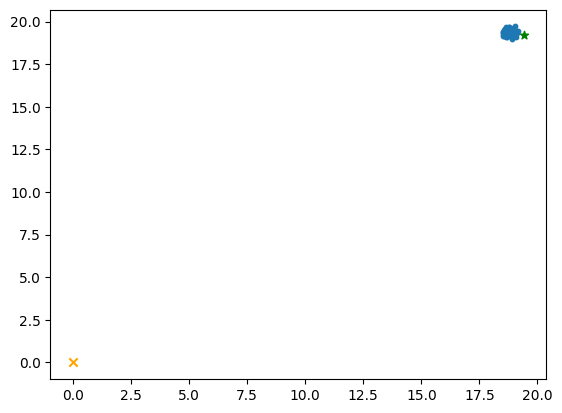

In [68]:
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
plt.scatter(x=observation[0], y=observation[1], marker='*', c='green')
plt.scatter(x=goal[0], y=goal[1], marker='x', c='orange')

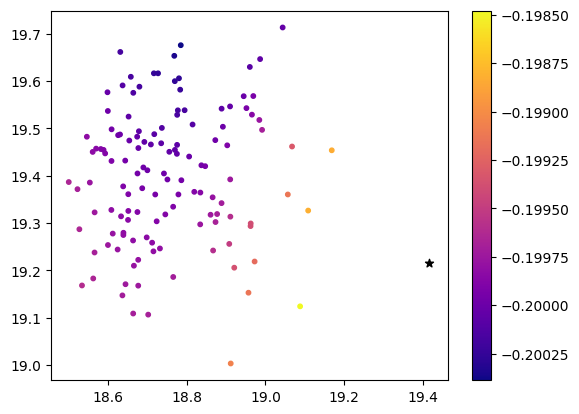

In [76]:
vs = agent.network.select('value')(observations[:, :2], goals=subgoals)

sc = plt.scatter(subgoals[:, 0], subgoals[:, 1], s=10, c=vs, cmap='plasma')
plt.scatter(observation[0], observation[1], marker='*', c='black')
plt.colorbar(sc)
plt.show()

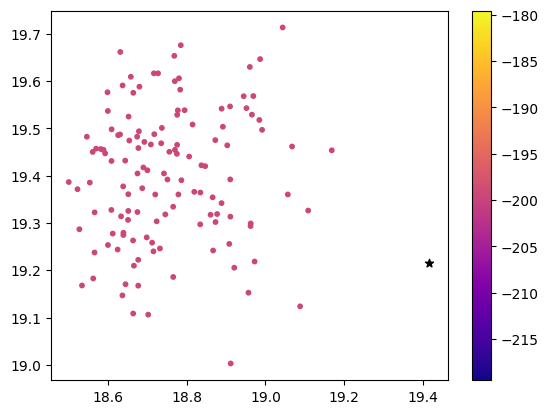

In [79]:
vs = dd(agent, observations[:, :2], goals=subgoals)

sc = plt.scatter(subgoals[:, 0], subgoals[:, 1], s=10, c=vs, cmap='plasma')
plt.scatter(observation[0], observation[1], marker='*', c='black')
plt.colorbar(sc)
plt.show()

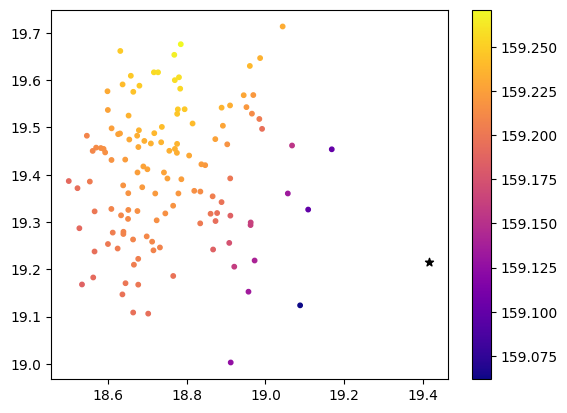

In [80]:
vs = agent.compute_dynamical_distance(observations[:, :2], goals=subgoals)

sc = plt.scatter(subgoals[:, 0], subgoals[:, 1], s=10, c=vs, cmap='plasma')
plt.scatter(observation[0], observation[1], marker='*', c='black')
plt.colorbar(sc)
plt.show()

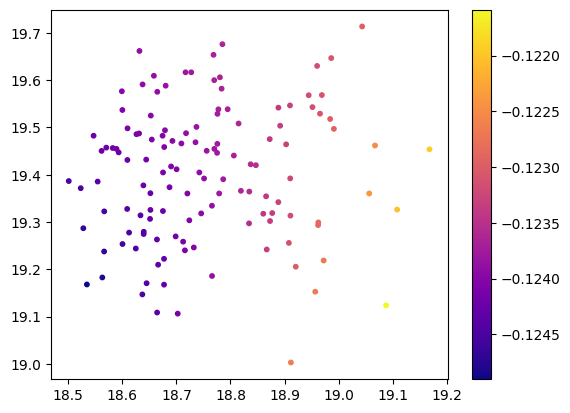

In [78]:
vs = agent.network.select('value')(subgoals, goals=goals)

sc = plt.scatter(subgoals[:, 0], subgoals[:, 1], s=10, c=vs, cmap='plasma')
# plt.scatter(goal[0], goal[1], marker='x', c='orange')
plt.colorbar(sc)
plt.show()

In [ ]:
filtered_goals = np.repeat(goal[None], len(filtered_subgoals), axis=0)
values = np.asarray(agent.network.select('value')(filtered_subgoals, goals=filtered_goals))